<a href="https://colab.research.google.com/github/polokocodes/Data-Science---ML-Projects/blob/main/EDA_Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
loan_data = pd.read_csv('/content/loan.csv')
loan_data.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [5]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [7]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
missing_values = loan_data.isnull().sum()

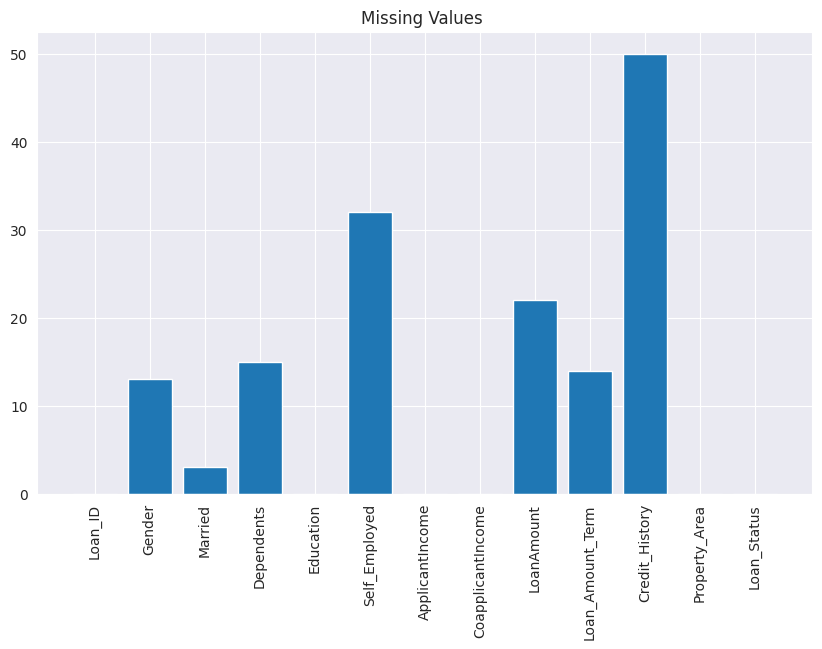

In [9]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
plt.title('Missing Values ')
plt.bar(missing_values.index, missing_values.values)
plt.xticks(rotation=90)
plt.show()

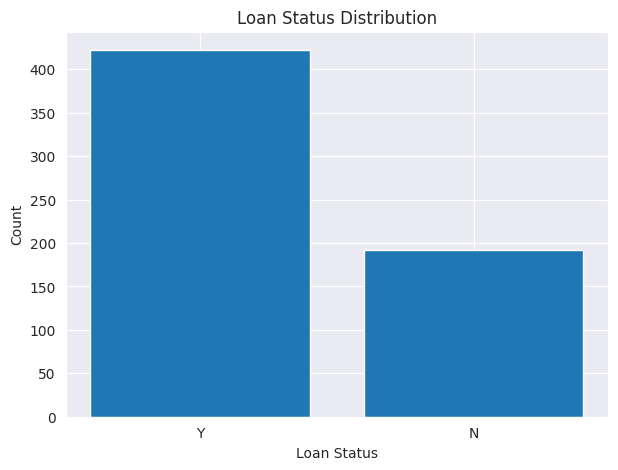

Loan status distribution:68.73%


In [15]:
#Loan Status distribution

plt.figure(figsize=(7,5))
plt.bar(x=loan_data['Loan_Status'].value_counts().index, height=loan_data['Loan_Status'].value_counts().values)
#plt.xticks(rotation=90)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()
loan_distrubution_per = (loan_data['Loan_Status'] == 'Y').mean() *100
print(f"Loan status distribution:{loan_distrubution_per:.2f}%")

In [11]:
# Loan status vs Categorical values
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [17]:
loan_data['Gender'].head()

,Gender
0,Male
1,Male
2,Male
3,Male
4,Male


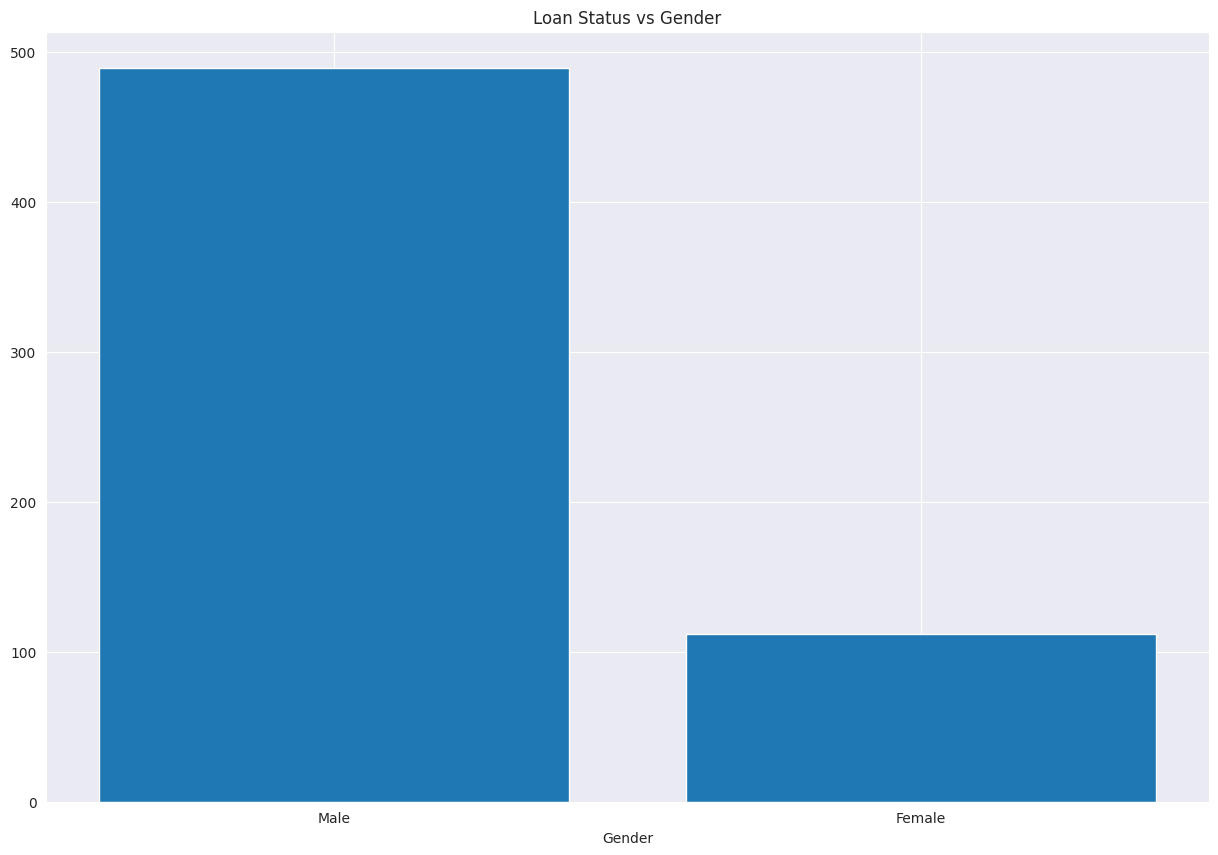

In [23]:
plt.figure(figsize=(15,10))
plt.bar(x=loan_data['Gender'].value_counts().index, height=loan_data['Gender'].value_counts().values)
plt.title("Loan Status vs Gender")
plt.xlabel("Gender")
plt.show()

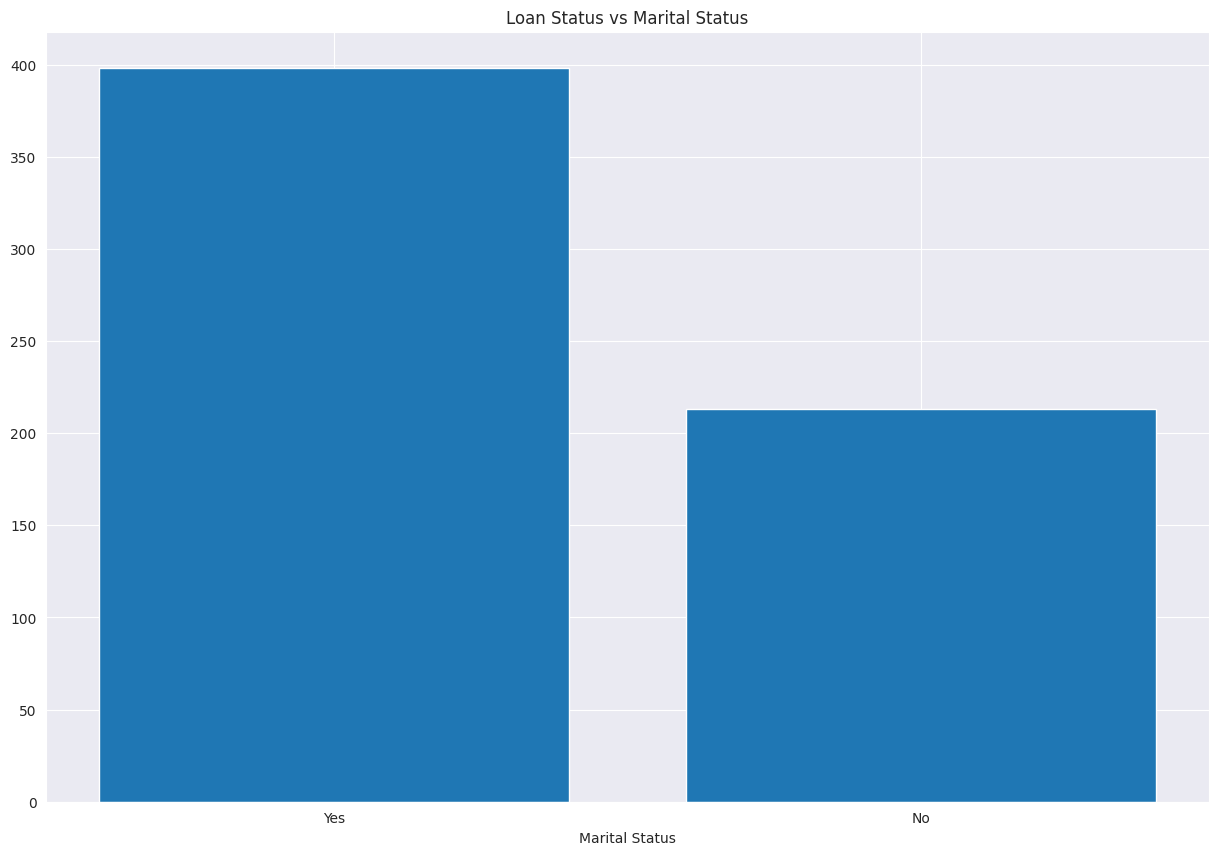

In [24]:
#Loan status vs Marital status
plt.figure(figsize=(15,10))
plt.bar(x=loan_data['Married'].value_counts().index, height=loan_data['Married'].value_counts().values)
plt.title("Loan Status vs Marital Status")
plt.xlabel("Marital Status")
plt.show()

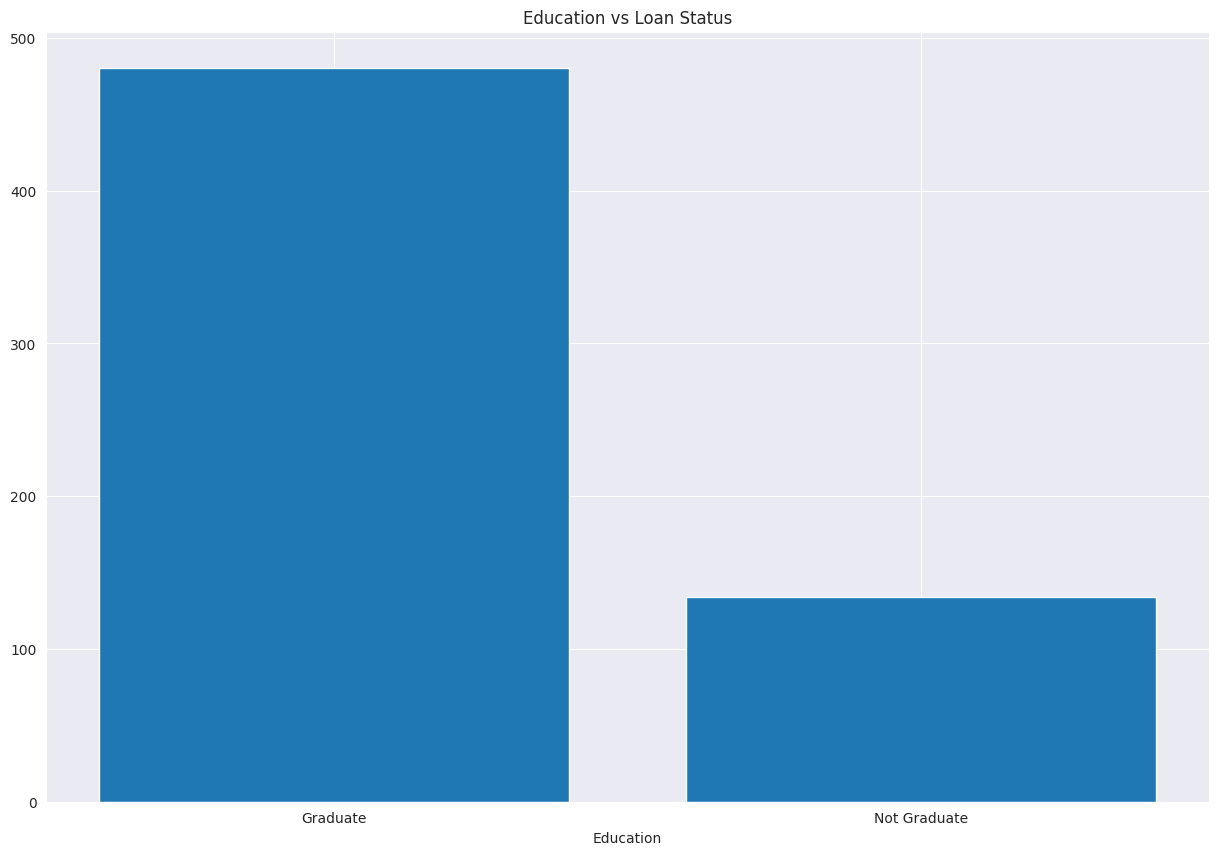

In [25]:
#Education vs Loan status
plt.figure(figsize=(15,10))
plt.bar(x=loan_data['Education'].value_counts().index, height=loan_data['Education'].value_counts().values)
plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.show()

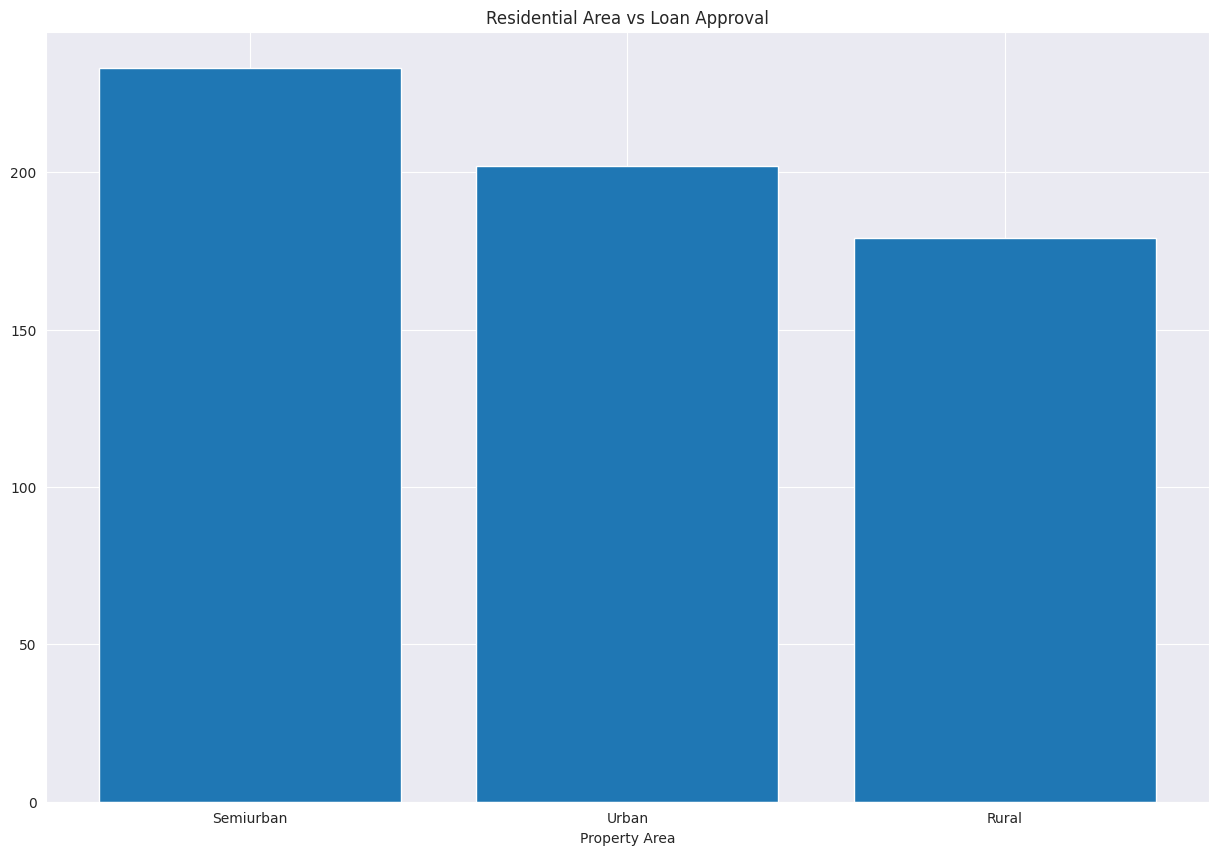

In [26]:
#Residential area vs loan approval
plt.figure(figsize=(15,10))
plt.bar(x=loan_data['Property_Area'].value_counts().index, height=loan_data['Property_Area'].value_counts().values)
plt.title("Residential Area vs Loan Approval")
plt.xlabel("Property Area")
plt.show()

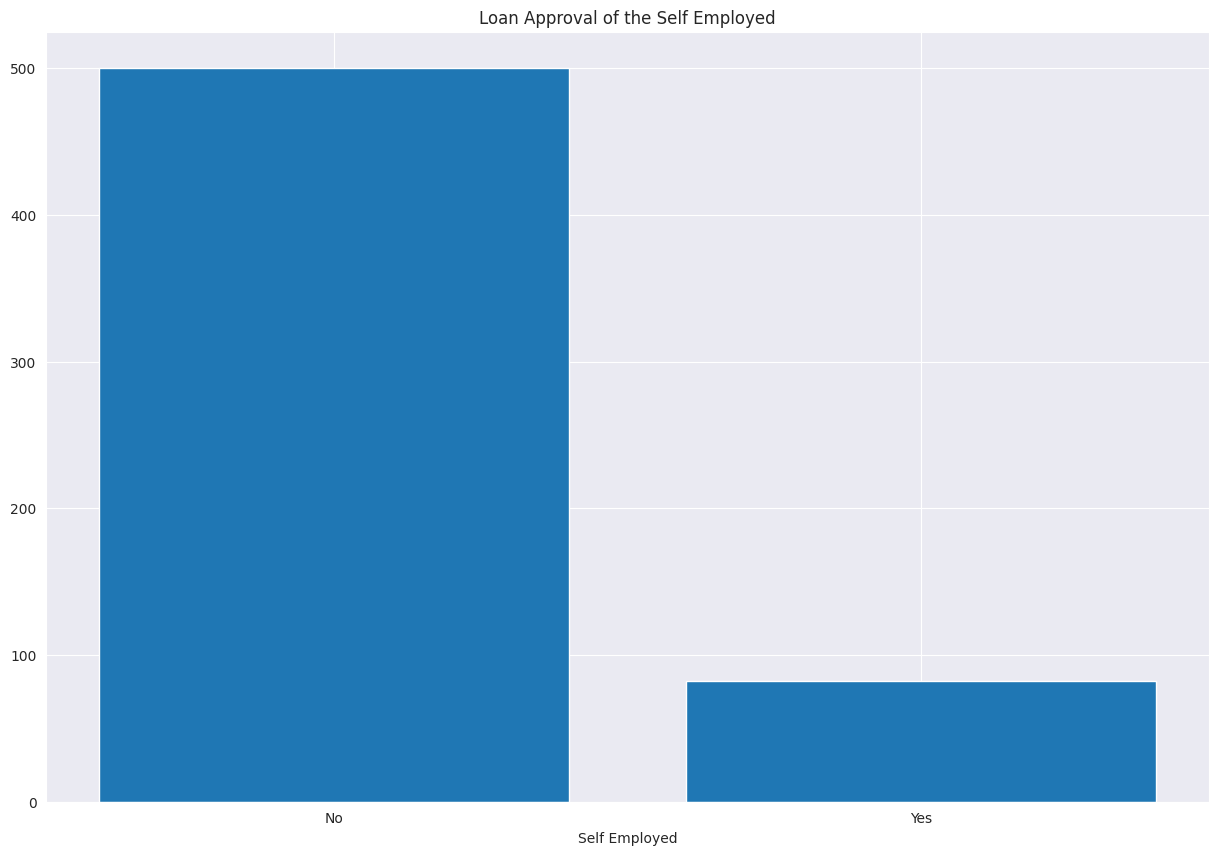

In [27]:
#Loan approval of the self employed
plt.figure(figsize=(15,10))
plt.bar(x=loan_data['Self_Employed'].value_counts().index, height=loan_data['Self_Employed'].value_counts().values)
plt.title("Loan Approval of the Self Employed")
plt.xlabel("Self Employed")
plt.show()

In [36]:
loan_data['ApplicantIncome'].value_counts()

,count
ApplicantIncome,
2500,9
4583,6
6000,6
2600,6
5000,5
...,...
11000,1
3416,1
1907,1


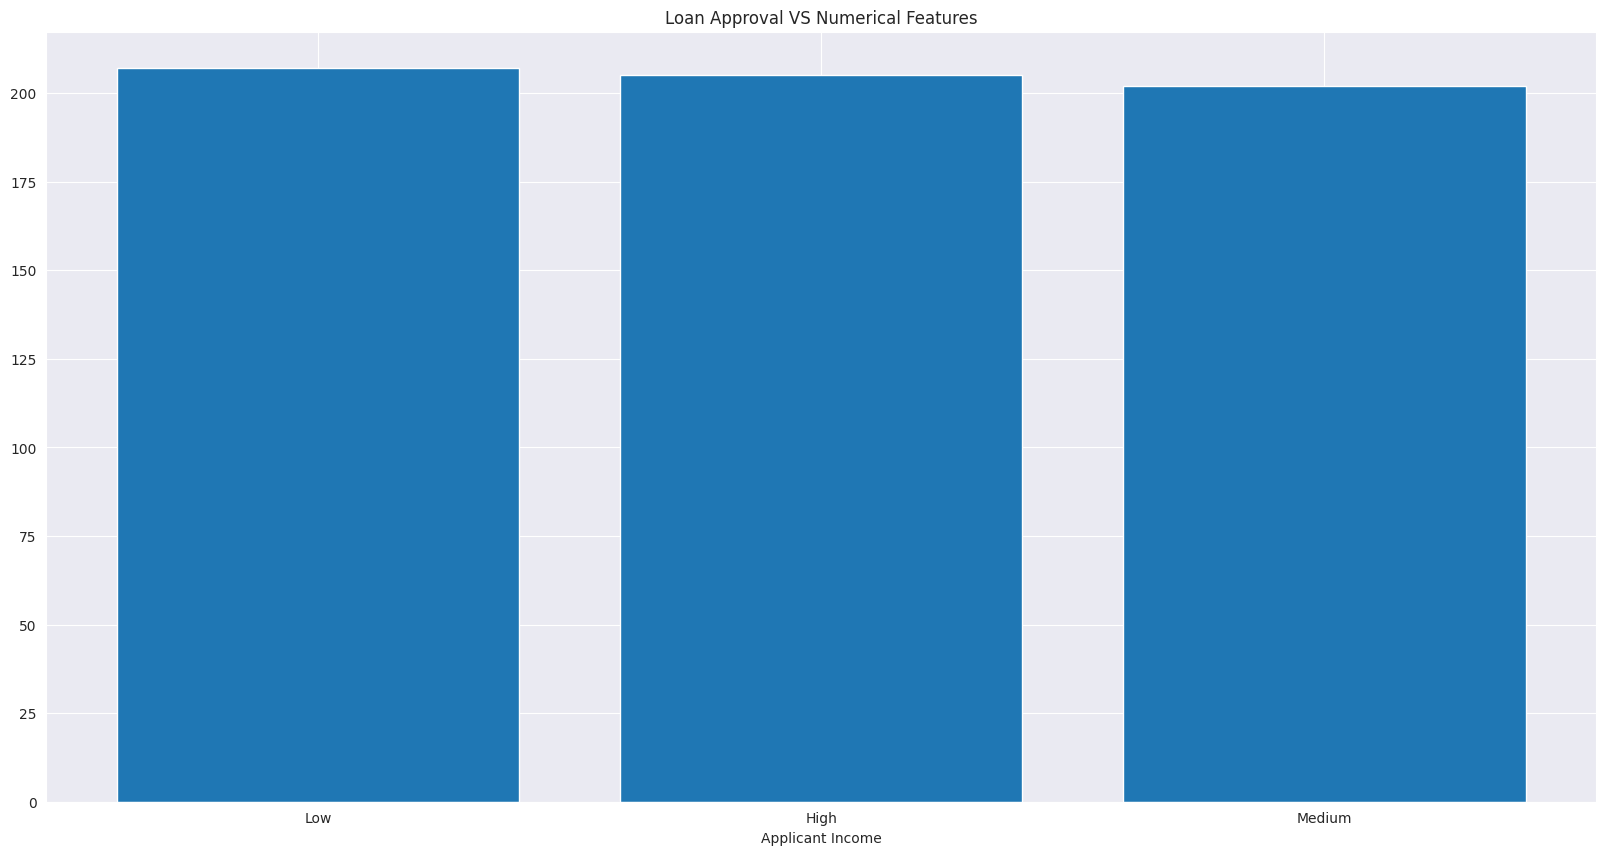

In [35]:
#Loan approval VS numerical features
income_bins = ['Low', 'Medium', 'High']
loan_data['Income_Category'] = pd.qcut(loan_data['ApplicantIncome'], q=3, labels= income_bins)
plt.figure(figsize=(20,10))
plt.bar(x=loan_data['Income_Category'].value_counts().index, height=loan_data['Income_Category'].value_counts().values)
plt.title("Loan Approval VS Numerical Features")
plt.xlabel("Applicant Income")
plt.show()

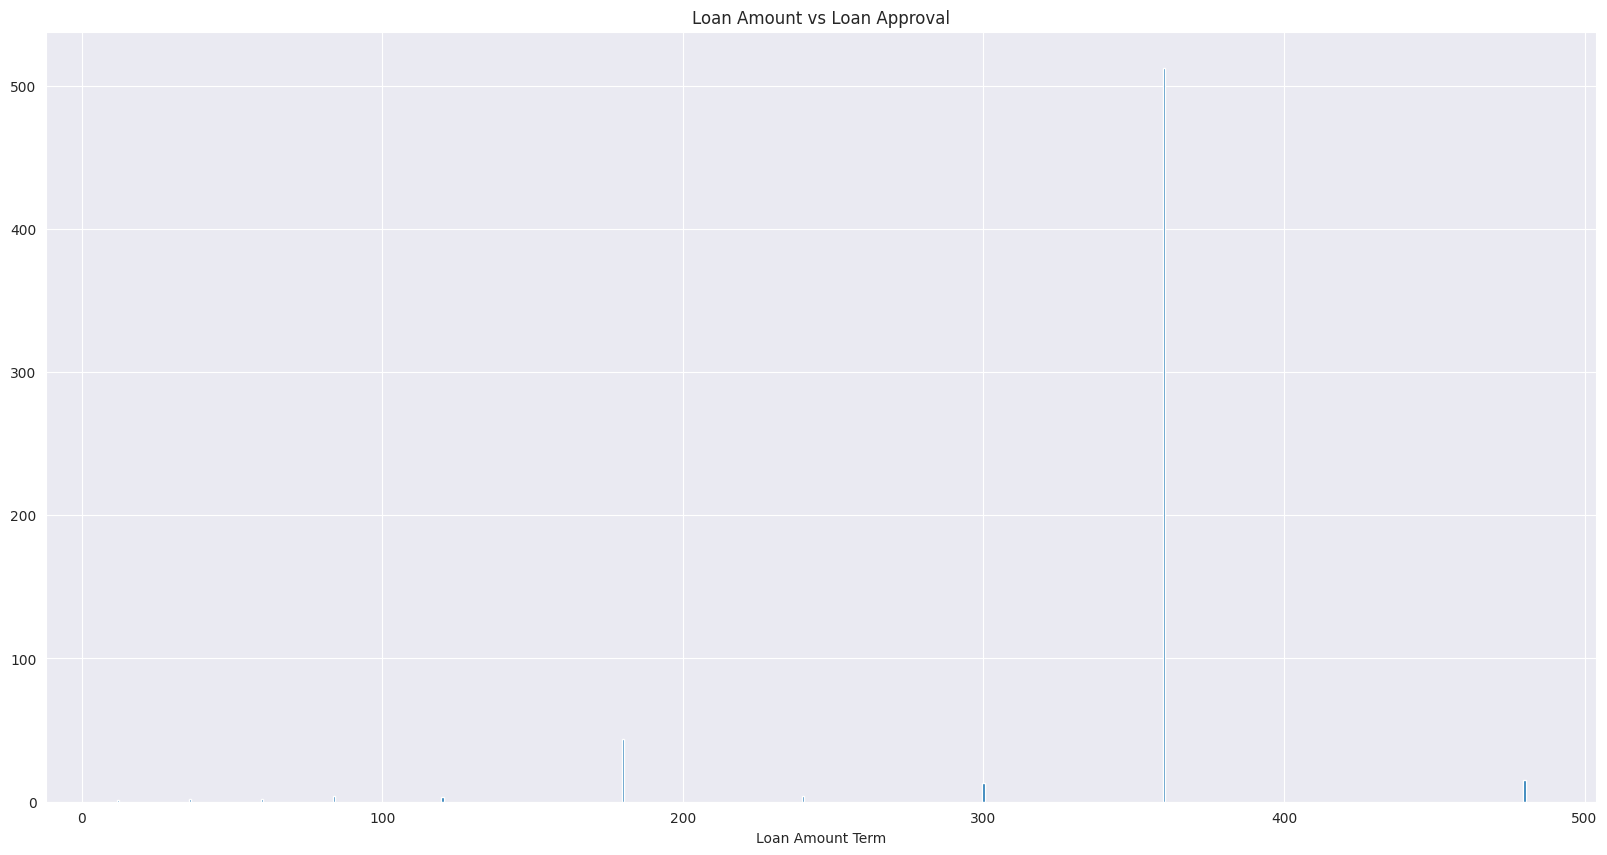

In [37]:
#Loan amount vs Loan approval
plt.figure(figsize=(20,10))
plt.bar(x=loan_data['Loan_Amount_Term'].value_counts().index, height=loan_data['Loan_Amount_Term'].value_counts().values)
plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Amount Term")
plt.show()